# Revisão de código 

Olá! 

Meu nome é Suelen. Estou feliz em revisar seu projeto hoje!

Quando vejo um erro pela primeira vez, apenas aponto. Deixarei você encontrá-lo e corrigi-lo sozinho. Além disso, ao longo do texto, farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Mas se você ainda não consegue lidar com essa tarefa, darei uma dica mais precisa na próxima iteração e também alguns exemplos práticos. Estarei aberto a feedbacks e discussões sobre o tema.

Você pode encontrar meus comentários em caixas verdes, amarelas ou vermelhas como estas:
<!--  -->

<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Sucesso. Tudo está correto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

Observações. Algumas recomendações.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário: </b> <a class="tocSkip"></a>

O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.
</div>



Você pode me responder usando isto:

<div class="alert alert-block alert-info">
    Resposta
<b></b> <a class="tocSkip"></a>
</div>



<div class="alert alert-block alert-danger">

<b>Comentário geral V1: </b> <a class="tocSkip"></a>


Parabéns pela conclusão do projeto, Daniel! 🎉

O seu trabalho já demonstra excelente qualidade! Como comentários positivos, destaco: 
    
    
- Código organizado e com comentários em cada etapa
- Boa análise crítica dos dados 
    
    
Para concluirmos a aprovação, precisamos fazer alguns ajustes. O ajuste principal é:

    - Análise de taxa de retenção
    - LTV por coortes
    - Taxa de ROI por coortes
    
    
    
    
Incluí comentários ao longo do código para te auxiliar nessa tarefa.
    
    
    

Fico à disposição para eventuais dúvidas. 

Boa sorte! 🍀
</div>

<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>  

Muuuito obrigada pelos ajustes! Projeto aprovado :) 



In [1]:
# Importar bibliotecas base
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# Definir caminhos dos ficheiros conforme pedido no enunciado
VISITS_PATH = "/datasets/visits_log_us.csv"
ORDERS_PATH = "/datasets/orders_log_us.csv"
COSTS_PATH = "/datasets/costs_us.csv"

In [3]:
# Carregar os CSVs tal como estão, para inspecionar estrutura e tipos
visits = pd.read_csv(VISITS_PATH, low_memory=False) #acessos
orders = pd.read_csv(ORDERS_PATH, low_memory=False) #pedidos
costs = pd.read_csv(COSTS_PATH, low_memory=False) #depesas de marketing

In [4]:
# Inspeção rápida: garante que carregou e mostra tipos atuais
print("visits:", visits.shape); visits.info()
print("\norders:", orders.shape); orders.info()
print("\ncosts:", costs.shape); costs.info()

visits: (359400, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB

orders: (50415, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB

costs: (2542, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Nul

In [5]:
#Amostras para ver formato das colunas
display(visits.head(3))
display(orders.head(3))
display(costs.head(3))

,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527


,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844


,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53


In [6]:
# VISITS — renomear para snake_case e tipificar
# Motivo: nomes consistentes e tipos corretos são essenciais para os groupby e as métricas
visits = visits.rename(columns={
    "Uid": "uid",
    "Device": "device",
    "Start Ts": "start_ts",
    "End Ts": "end_ts",
    "Source Id": "source_id"
})
visits["uid"] = visits["uid"].astype("string")
visits["device"] = visits["device"].astype("string")
visits["source_id"] = pd.to_numeric(visits["source_id"], errors="coerce").astype("Int64")
visits["start_ts"] = pd.to_datetime(visits["start_ts"],errors="coerce")
visits["end_ts"] = pd.to_datetime(visits["end_ts"], errors="coerce")
# Duração da sessão (min) — necessária para métricas de produto
visits["session_duration_min"] = (visits["end_ts"] - visits["start_ts"]).dt.total_seconds()/60

In [7]:
# ORDERS — renomear e tipificar
# Motivo: revenue como numérico e buy_ts como datetime para cálculos de conversão e LTV.
orders = orders.rename(columns={"Uid":"uid","Buy Ts":"buy_ts","Revenue":"revenue"})
orders["uid"] = orders["uid"].astype("string")
orders["buy_ts"] = pd.to_datetime(orders["buy_ts"], errors="coerce")
orders["revenue"] = pd.to_numeric(orders["revenue"], errors="coerce")

In [8]:
# COSTS — renomear e tipificar
# Motivo: dt como data normalizada para ligar a custos diários por origem.
costs ["source_id"] = pd.to_numeric(costs["source_id"], errors="coerce").astype("Int64")
costs["dt"] = pd.to_datetime(costs["dt"], errors="coerce").dt.normalize()
costs["costs"] = pd.to_numeric(costs["costs"], errors="coerce")

In [9]:
# Verificação final de tipos (e confirmação de shapes)
print("visits dtypes:\n", visits.dtypes)
print("\norders dtypes:\n", orders.dtypes)
print("\ncosts dtypes:\n", costs.dtypes)

visits dtypes:
 device                          string
end_ts                  datetime64[ns]
source_id                        Int64
start_ts                datetime64[ns]
uid                             string
session_duration_min           float64
dtype: object

orders dtypes:
 buy_ts     datetime64[ns]
revenue           float64
uid                string
dtype: object

costs dtypes:
 source_id             Int64
dt           datetime64[ns]
costs               float64
dtype: object


In [10]:
##passo 2##
# Criar coluna de data (dia) a partir do início da sessão
visits["date"] = visits["start_ts"].dt.normalize()
# Segurança: descartar sessões sem uid ou data
visits_prod = visits.dropna(subset=["uid", "date"]).copy()
print("Período de dados:", visits_prod["date"].min().date()), "até", visits_prod["date"].max().date()
print("Sessões:", len(visits_prod), "| Utilizadores únicos:", visits_prod["uid"].nunique())

Período de dados: 2017-06-01
Sessões: 359400 | Utilizadores únicos: 228169


In [11]:

# 2.B — DAU / WAU / MAU (calendário e janela móvel corrigida)

import pandas as pd

# Garantir que temos a coluna 'date' (caso ainda não tenhas corrido o 2.A)
if "date" not in visits.columns:
    visits["date"] = visits["start_ts"].dt.normalize()

visits_prod = visits.dropna(subset=["uid", "date"]).copy()

# --- 1) Únicos por período calendário (dia, semana, mês) ---
dau = visits_prod.groupby("date")["uid"].nunique().rename("DAU")

# Semana calendário (segunda-feira como início). Ajusta para 'W-SUN' se precisares domingo.
wau_calendar = (
    visits_prod
    .set_index("date")
    .groupby(pd.Grouper(freq="W-MON"))["uid"]
    .nunique()
    .rename("WAU_cal")
)

# Mês calendário (início do mês)
mau_calendar = (
    visits_prod
    .set_index("date")
    .groupby(pd.Grouper(freq="MS"))["uid"]
    .nunique()
    .rename("MAU_cal")
)

# --- 2) Únicos por janela móvel (rolling) 7 e 30 dias ---
# Conjuntos de utilizadores por dia
daily_uid_sets = visits_prod.groupby("date")["uid"].agg(lambda s: set(s))

def rolling_unique_counts(sets_series, window):
    """Conta utilizadores únicos numa janela deslizante de 'window' dias."""
    res = []
    buffer = []
    for s in sets_series:
        buffer.append(s)
        if len(buffer) > window:
            buffer.pop(0)
        res.append(len(set().union(*buffer)) if buffer else 0)
    return pd.Series(res, index=sets_series.index)

wau = rolling_unique_counts(daily_uid_sets, 7).rename("WAU_rolling")
mau = rolling_unique_counts(daily_uid_sets, 30).rename("MAU_rolling")

# --- Resumo rápido ---
print("Médias no período (valores aproximados):")
print("DAU médio:", round(dau.mean(), 1))
print("WAU_cal médio:", round(wau_calendar.mean(), 1), "| WAU_rolling médio:", round(wau.mean(), 1))
print("MAU_cal médio:", round(mau_calendar.mean(), 1), "| MAU_rolling médio:", round(mau.mean(), 1))

# (Opcional) DataFrame consolidado diário para facilitar gráficos depois
metrics_daily = (
    pd.concat([dau, wau, mau], axis=1)
      .rename(columns={"DAU": "dau", "WAU_rolling": "wau_rolling", "MAU_rolling": "mau_rolling"})
)
display(metrics_daily.head())


Médias no período (valores aproximados):
DAU médio: 908.0
WAU_cal médio: 5722.2 | WAU_rolling médio: 5759.9
MAU_cal médio: 23228.4 | MAU_rolling médio: 22094.1


,dau,wau_rolling,mau_rolling
date,,,
2017-06-01,605,605,605
2017-06-02,608,1169,1169
2017-06-03,445,1580,1580
2017-06-04,476,2021,2021
2017-06-05,820,2767,2767


In [12]:
# Sessões por dia
sessions_per_day = visits_prod.groupby("date").size().rename("sessions")
print("Sessões/dia — média:", sessions_per_day.mean().round(1), "| mediana:", sessions_per_day.median())

# Comprimento das sessões (em minutos) — já criámos 'session_duration_min' no Passo 1
# Limpeza leve: remover NaN e outliers extremos opcionais (ex.: > 95º percentil para estatísticas robustas)
dur = visits_prod["session_duration_min"].dropna()
p95 = dur.quantile(0.95)
dur_clip = dur.clip(upper=p95)  # apenas para métricas robustas; não altera os dados originais

print("\nDuração da sessão (min) — sem outliers extremos:")
print(dur_clip.describe(percentiles=[0.25,0.5,0.75]).round(2))

# Duração média por dispositivo (útil para o Passo 2 depois, mas já deixamos pronto)
dur_by_device = visits_prod.groupby("device")["session_duration_min"].median().sort_values(ascending=False)
print("\nMediana da duração por device (min):")
print(dur_by_device.round(2))


Sessões/dia — média: 987.4 | mediana: 1003.0

Duração da sessão (min) — sem outliers extremos:
count    359400.00
mean          9.47
std          10.76
min         -46.00
25%           2.00
50%           5.00
75%          14.00
max          38.00
Name: session_duration_min, dtype: float64

Mediana da duração por device (min):
device
desktop    6.0
touch      3.0
Name: session_duration_min, dtype: float64


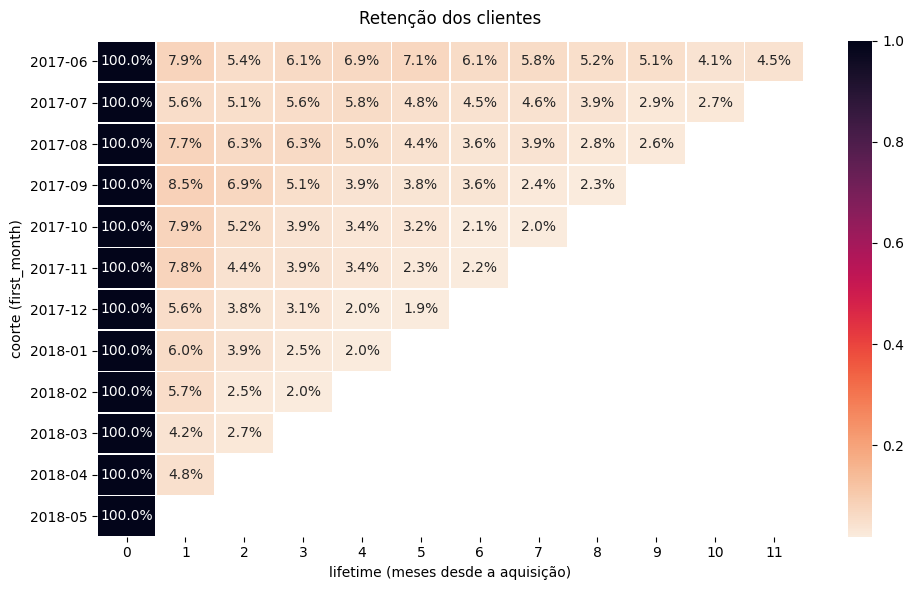

In [13]:

# === Retenção por coorte + heatmap (célula única) ===


# 0) Garante que 'visits' tem as colunas exigidas
assert {'uid','start_ts'}.issubset(visits.columns), "A tabela 'visits' precisa de 'uid' e 'start_ts'"

# 1) Preparar visitas mensais (1 linha por uid-mês)
df_visits = (
    visits.loc[:, ["uid", "start_ts"]]
          .dropna(subset=["uid", "start_ts"])
          .copy()
)
df_visits["month"] = df_visits["start_ts"].dt.to_period("M")
first_month_by_uid = df_visits.groupby("uid")["month"].min().rename("first_month")
df_visits = df_visits.join(first_month_by_uid, on="uid")
df_visits = df_visits.drop_duplicates(subset=["uid", "month"])

# 2) Lifetime em meses (usar .n como no enunciado)
df_visits["lifetime"] = (df_visits["month"] - df_visits["first_month"]).apply(lambda x: x.n)
df_visits = df_visits[df_visits["lifetime"] >= 0]

# 3) Contagem e tamanho da coorte
cohort = (df_visits
          .groupby(["first_month","lifetime"], as_index=False)
          .agg(uid=("uid","nunique")))
inicial = cohort[cohort["lifetime"]==0][["first_month","uid"]].rename(columns={"uid":"users"})

# 4) Retenção e pivot
cohort = cohort.merge(inicial, on="first_month", how="left")
cohort["retention"] = cohort["uid"] / cohort["users"]
retention_pivot = (cohort
                   .pivot_table(index="first_month", columns="lifetime",
                                values="retention", aggfunc="mean")
                   .sort_index()
                   .sort_index(axis=1))

# 5) Heatmap com percentagens nas células
retp = retention_pivot.copy()
retp.index = retp.index.astype(str)
mask = retp.isna()

plt.figure(figsize=(10,6))
ax = sns.heatmap(
    retp,
    mask=mask,
    annot=True,
    fmt=".1%",
    cmap="rocket_r",
    cbar=True,
    linewidths=0.5,
    linecolor="white"
)
ax.set_title("Retenção dos clientes", pad=12)
ax.set_xlabel("lifetime (meses desde a aquisição)")
ax.set_ylabel("coorte (first_month)")
ax.set_xticklabels([str(c) for c in retp.columns], rotation=0)
ax.set_yticklabels(retp.index, rotation=0)
plt.tight_layout()
plt.show()




<div class="alert alert-block alert-danger">

<b>Comentário: </b> <a class="tocSkip"></a>
    
    
E necessario realizar a taxa de retenção deve ser realizada por coorte.

O passo a passo é o seguinte:
    
1. Você precisa pegar a data do primeiro acesso de cada usuário
2. Para calcular o intervalo ou cohort de acesso para cada usuário, você precisa calcular o intervalo entre o acesso atual e o primeiro acesso:</s>
3. A partir desses dados, você pode criar uma tabela dinâmica (`pivot_table`) que indexa por cada mês do conjunto de dados e calcula a quantidade de usuários que teve o primeiro acesso naquele mês e voltou a acessar no futuro (`cohort`): 1 mês depois, 2 meses depois, etc. 


Exemplo: 

```python

# Calcula a vida útil de cada visita em meses
df_visits['lifetime'] = (df_visits['month'] - df_visits['first_month']).apply(lambda x: x.n)

# Calcula a coorte de usuários por mês de primeira visita e tempo de vida
cohort = df_visits.groupby(['first_month', 'lifetime']).agg({'uid': 'nunique'}).reset_index()

# Seleciona a coorte inicial (lifetime == 0) e renomeia a coluna de contagem de usuários
inicial = cohort[cohort['lifetime'] == 0][['first_month', 'uid']]
inicial = inicial.rename(columns={'uid': 'users'})

# Junta a coorte inicial com a coorte completa e calcula a taxa de retenção
cohort = cohort.merge(inicial, on='first_month')
cohort['retention'] = cohort['uid'] / cohort['users']

# Cria uma tabela dinâmica de retenção por mês de primeira visita e tempo de vida
retention_pivot = cohort.pivot_table(index='first_month', columns='lifetime', values='retention', aggfunc='sum')

# Imprime a tabela de retenção
print(retention_pivot)
```

O output deve ser semelhante a esse:
</div>




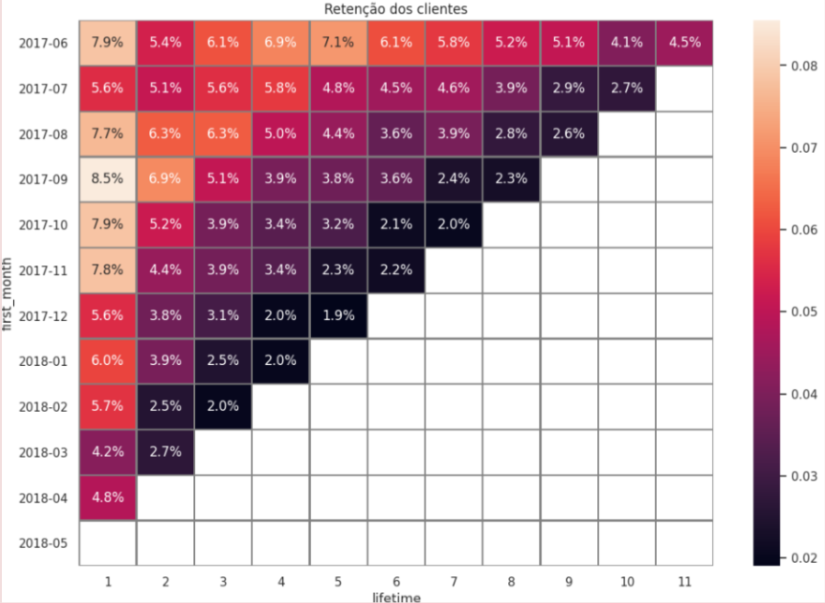

In [14]:
# Pedidos por dia / semana / mês (contagem)
orders["buy_date"] = orders["buy_ts"].dt.normalize()

orders_per_day   = orders.groupby("buy_date").size().rename("orders")
orders_per_week  = orders.set_index("buy_date").groupby(pd.Grouper(freq="W-MON")).size().rename("orders")
orders_per_month = orders.set_index("buy_date").groupby(pd.Grouper(freq="MS")).size().rename("orders")

print("Média de pedidos/dia:", round(orders_per_day.mean(),1))
print("Média de pedidos/semana:", round(orders_per_week.mean(),1))
print("Média de pedidos/mês:", round(orders_per_month.mean(),1))

# Nº de pedidos por utilizador (distribuição)
orders_per_user = orders.groupby("uid").size().rename("n_orders")
display(orders_per_user.describe().round(2))

# % de clientes com 1 pedido vs 2+ pedidos
share_1  = (orders_per_user.eq(1).mean()*100).round(1)
share_2p = (orders_per_user.ge(2).mean()*100).round(1)
print(f"% de clientes com 1 pedido: {share_1}% | com 2+ pedidos: {share_2p}%")


Média de pedidos/dia: 138.5
Média de pedidos/semana: 951.2
Média de pedidos/mês: 3878.1


count    36523.00
mean         1.38
std          3.45
min          1.00
25%          1.00
50%          1.00
75%          1.00
max        239.00
Name: n_orders, dtype: float64

% de clientes com 1 pedido: 82.8% | com 2+ pedidos: 17.2%


In [15]:
# (segurança) garantir tipos
visits["start_ts"] = pd.to_datetime(visits["start_ts"])
orders["buy_ts"]   = pd.to_datetime(orders["buy_ts"])
orders["revenue"]  = pd.to_numeric(orders["revenue"], errors="coerce")

# 1) users_reg (para o device do 1.º acesso)
users_reg = (
    visits.sort_values(["uid", "start_ts"])
          .groupby("uid", as_index=False)
          .agg(first_visit_ts=("start_ts", "first"),
               first_device=("device", "first"))
)

# 2) AOV global
aov_global = orders["revenue"].mean()
print("AOV global:", round(aov_global, 2))

# 3A) AOV por mês usando Period (versão-agnóstico)
orders["buy_month"] = orders["buy_ts"].dt.to_period("M")
aov_by_month = (
    orders.groupby("buy_month")["revenue"]
          .mean()
          .rename("AOV")
)
display(aov_by_month.head())

# (Opcional) se precisares MESMO de DatetimeIndex para plot com resample/Grouper:
# orders["buy_month_dt"] = orders["buy_ts"].dt.to_period("M").dt.to_timestamp()  # início do mês (how='start' por omissão)
# aov_by_month = (orders.set_index("buy_month_dt")
#                        .groupby(pd.Grouper(freq="MS"))["revenue"]
#                        .mean()
#                        .rename("AOV"))

# 4) AOV por device do 1.º acesso
aov_by_device = (
    orders.merge(users_reg[["uid","first_device"]], on="uid", how="left")
          .groupby("first_device")["revenue"].mean()
          .sort_values(ascending=False)
          .rename("AOV")
          .round(2)
)
display(aov_by_device)


AOV global: 5.0


buy_month
2017-06    4.060106
2017-07    5.306589
2017-08    4.847139
2017-09    5.416448
2017-10    4.928280
Freq: M, Name: AOV, dtype: float64

first_device
desktop    5.16
touch      4.29
Name: AOV, dtype: float64

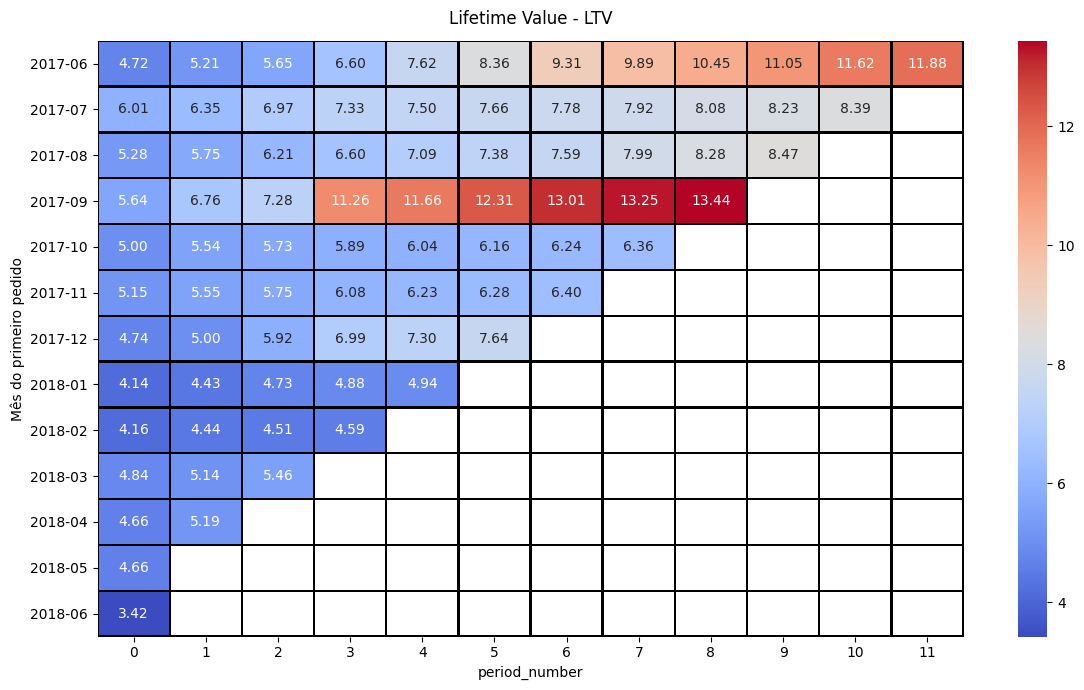

In [16]:
# === LTV acumulado por coorte do primeiro pedido (heatmap estilo screenshot) ===

# 0) Segurança: tipos
orders["buy_ts"]  = pd.to_datetime(orders["buy_ts"])
orders["revenue"] = pd.to_numeric(orders["revenue"], errors="coerce")

# 1) Mês de cada pedido (Period[M])
df_logs = orders.copy()
df_logs["order_month"] = df_logs["buy_ts"].dt.to_period("M")

# 2) Mês do primeiro pedido por utilizador (coorte de compradores)
first_order_month = (
    df_logs.groupby("uid")["order_month"]
           .min()
           .reset_index()
           .rename(columns={"order_month": "first_order_month"})
)

# 3) Juntar ao dataset original
cohort = pd.merge(df_logs, first_order_month, on="uid", how="left")

# 4) Diferença em meses entre o pedido atual e o primeiro pedido
cohort["month_diff"] = (cohort["order_month"] - cohort["first_order_month"]).apply(lambda x: x.n)
cohort = cohort[cohort["month_diff"] >= 0]  # sanidade

# 5) Tamanho da coorte (nº de compradores distintos no mês do 1.º pedido)
cohort_sizes = (
    cohort.groupby("first_order_month")["uid"]
          .nunique()
          .reset_index()
          .rename(columns={"uid": "n_buyers"})
)

# 6) LTV instantâneo = receita / n_buyers da coorte
cohort = pd.merge(cohort, cohort_sizes, on="first_order_month", how="left")
cohort["ltv"] = cohort["revenue"] / cohort["n_buyers"]

# 7) Tabela dinâmica (linhas = coorte, colunas = month_diff)
output = cohort.pivot_table(
    index="first_order_month",
    columns="month_diff",
    values="ltv",
    aggfunc="sum"
)

# 8) LTV acumulado ao longo dos períodos (por linha)
output = output.sort_index(axis=1)             # garantir colunas 0..N
ltv_cumsum = output.cumsum(axis=1).round(2)

# 9) Reindexar colunas para 0..max e manter NaN (cria o “triângulo” vazio)
max_diff = int(cohort["month_diff"].max()) if len(cohort) else 0
ltv_cumsum = ltv_cumsum.reindex(columns=range(0, max_diff + 1))

# 10) Heatmap (anotações, grelha preta, esquema azul→vermelho)
plot_df = ltv_cumsum.copy()
plot_df.index = plot_df.index.astype(str)  # rótulos 'YYYY-MM'

mask = plot_df.isna()

plt.figure(figsize=(12, 7))
ax = sns.heatmap(
    plot_df,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    linewidths=1.0,
    linecolor="black"
)
ax.set_title("Lifetime Value - LTV", pad=12)
ax.set_ylabel("Mês do primeiro pedido")
ax.set_xlabel("period_number")

# ticks como 0,1,2,...
ax.set_xticklabels([str(c) for c in plot_df.columns], rotation=0)
ax.set_yticklabels(plot_df.index, rotation=0)

plt.tight_layout()
plt.show()


<div class="alert alert-block alert-danger">
<b> Comentário: </b> <a class="tocSkip"></a>
    
A análise LTV necessita de ajustes. 

Adiciono abaixo um passo a passo mais detalhado para a resolução do problema:
    
Passo 1: Criar Coluna de Mês do Pedido
Primeiro, criamos uma nova coluna em nosso DataFrame que representa o mês de cada compra.

```python

# Criando a coluna 'order_month' a partir da coluna 'buy_ts' que contém a data de compra
df_logs['order_month'] = df_logs['buy_ts'].dt.to_period('M')
```
Passo 2: Identificar o Mês da Primeira Compra
Em seguida, encontramos o mês da primeira compra para cada usuário.

```python
# Primeira Compra
first_order_month = df_logs.groupby("uid")['order_month'].min().reset_index().rename(columns={'order_month': 'first_order_month'})
```
Passo 3: Mesclar Dados de Primeira Compra com o DataFrame Original
Agora, mesclamos o DataFrame original com o DataFrame que contém a data da primeira compra de cada usuário.

```python
# Mesclando o DataFrame original com o DataFrame que contém a data da primeira compra de cada usuário
cohort = pd.merge(df_logs, first_order_month, on='uid')
```
Passo 4: Calcular Diferença em Meses
Calculamos a diferença em meses entre o mês da compra atual e o mês da primeira compra.

```python
# Calculando a diferença em meses entre a compra atual e a primeira compra
cohort['month_diff'] = (cohort['order_month'].astype('int64') - cohort['first_order_month'].astype('int64'))
```
Passo 5: Calcular o Número de Compradores por Coorte
Agora, calculamos quantos compradores existem em cada coorte.

```python
# Calculando o número de compradores por coorte
cohort_sizes = cohort.groupby('first_order_month')['uid'].nunique().reset_index()
cohort_sizes.rename(columns={'uid': 'n_buyers'}, inplace=True)
```
Passo 6: Mesclar Tamanhos de Coorte com o DataFrame

Mesclamos o DataFrame de tamanhos de coorte com o DataFrame principal para obter as informações de compradores.

```python
# Mesclando o DataFrame de cohort sizes com o DataFrame original
cohort = pd.merge(cohort, cohort_sizes, left_on='first_order_month', right_on='first_order_month')
```
Passo 7: Calcular LTV
Agora podemos calcular o LTV dividindo a receita pela quantidade de compradores para cada coorte.

```python
# Calculando o LTV para cada coorte e período de tempo (em meses) após a primeira compra
cohort['ltv'] = cohort['revenue'] / cohort['n_buyers']
```
Passo 8: Criar uma Tabela Dinâmica
Criamos uma tabela dinâmica para organizar os dados de LTV.

```python
# Criando a Tabela Dinâmica
output = cohort.pivot_table(
    index='first_order_month',
    columns='month_diff',
    values='ltv',
    aggfunc='sum'
)
```
Passo 9: Calcular LTV Acumulado
Calculamos o LTV acumulado ao longo do tempo para cada coorte.

```python
# Calculando o LTV acumulado ao longo do tempo para cada coorte
ltv_cumsum = output.cumsum(axis=1).round(2)
```
Passo 10: Substituir Strings Vazias por NaN
Substituímos as strings vazias por NaN para evitar problemas na visualização.

```python

# Substituindo strings vazias por NaN
ltv_cumsum.replace('', np.nan, inplace=True)
```
Passo 11: Gerar o Heatmap
Por fim, geramos um heatmap para visualizar o LTV acumulado por coorte e período.


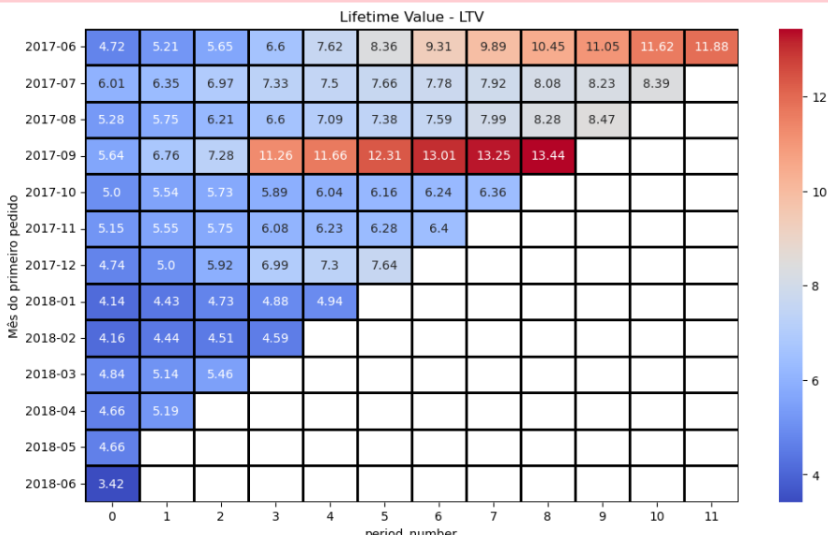

</div>



In [17]:
#3.Marketing 
#gastos totais
total_cost = costs["costs"].sum()
print("Gasto total em marketing:", round(total_cost, 2))

#Gastos por origem
cost_by_source = costs.groupby("source_id", as_index=False)["costs"].sum().sort_values("costs", ascending=False)
display(cost_by_source.head())

#gastos por mês (totais e por origem)
costs["month"] = costs["dt"].values.astype("datetime64[M]")

cost_by_month = costs.groupby("month", as_index=False)["costs"].sum()
display(cost_by_month.head())

cost_by_source_month = costs.groupby(["source_id","month"], as_index=False)["costs"].sum()
display(cost_by_source_month.head())

Gasto total em marketing: 329131.62


,source_id,costs
2,3,141321.63
3,4,61073.60
4,5,51757.10
1,2,42806.04
0,1,20833.27


,month,costs
0,2017-06-01,18015.00
1,2017-07-01,18240.59
2,2017-08-01,14790.54
3,2017-09-01,24368.91
4,2017-10-01,36322.88


,source_id,month,costs
0,1,2017-06-01,1125.61
1,1,2017-07-01,1072.88
2,1,2017-08-01,951.81
3,1,2017-09-01,1502.01
4,1,2017-10-01,2315.75


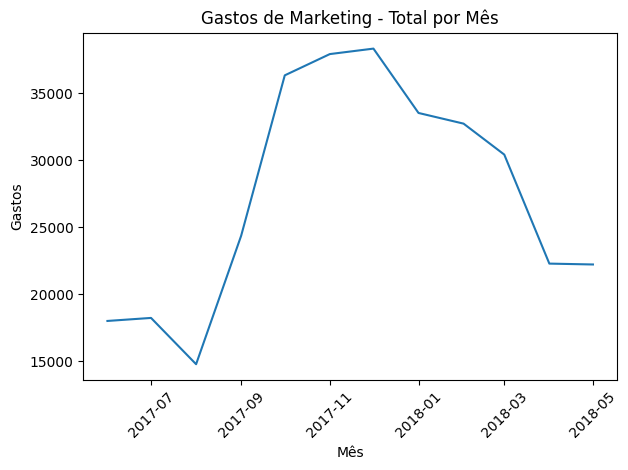

In [18]:
#gráfico
plt.figure()
plt.plot(cost_by_month["month"], cost_by_month["costs"])
plt.title("Gastos de Marketing - Total por Mês")
plt.xlabel("Mês")
plt.ylabel("Gastos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
#CAC por origem
# === CAC por origem (agregado e por mês de aquisição) ===
import numpy as np
import pandas as pd

# 0) segurança de tipos
visits["start_ts"] = pd.to_datetime(visits["start_ts"])
orders["buy_ts"]   = pd.to_datetime(orders["buy_ts"])
costs["month"]     = pd.to_datetime(costs["month"], errors="coerce")  # se já for Period, converto abaixo
costs["costs"]     = pd.to_numeric(costs["costs"], errors="coerce")

# 1) users_reg completo (precisa de first_source_id!)
users_reg = (
    visits.sort_values(["uid", "start_ts"])
          .groupby("uid", as_index=False)
          .agg(first_visit_ts=("start_ts", "first"),
               first_source_id=("source_id", "first"),
               first_device=("device", "first"))
)

# 2) compradores (1.ª compra) + origem do 1.º acesso
buyers = (
    orders.sort_values(["uid", "buy_ts"])
          .groupby("uid", as_index=False)
          .agg(first_buy_ts=("buy_ts", "first"))
          .merge(users_reg[["uid", "first_source_id", "first_device", "first_visit_ts"]],
                 on="uid", how="left")
)
buyers["is_customer"] = True

# 3) CAC agregado por origem
customers_by_source = (
    buyers.groupby("first_source_id", as_index=False)["uid"]
          .nunique().rename(columns={"uid": "n_customers"})
)
cost_by_source = costs.groupby("source_id", as_index=False)["costs"].sum()

cac_by_source = (
    cost_by_source.merge(customers_by_source,
                         left_on="source_id", right_on="first_source_id", how="left")
                  .drop(columns=["first_source_id"])
                  .fillna({"n_customers": 0})
)
# evitar divisão por zero -> NaN (ou usa np.inf se preferires)
cac_by_source["CAC_total"] = np.where(
    cac_by_source["n_customers"] > 0,
    cac_by_source["costs"] / cac_by_source["n_customers"],
    np.nan
)
cac_by_source = cac_by_source.sort_values("CAC_total", ascending=True)
display(cac_by_source)

# 4) CAC por mês de aquisição (mês da 1.ª compra), por origem
# usar Period[M] para uniformizar com quaisquer versões do pandas
buyers["acq_month"] = buyers["first_buy_ts"].dt.to_period("M")

# garantir que costs['month'] também é Period[M]
if np.issubdtype(costs["month"].dtype, np.datetime64):
    costs["month"] = costs["month"].dt.to_period("M")
elif costs["month"].dtype == "period[M]":
    pass
else:
    # última linha de defesa: tentar converter texto -> datetime -> period
    costs["month"] = pd.to_datetime(costs["month"], errors="coerce").dt.to_period("M")

customers_by_source_month = (
    buyers.groupby(["first_source_id", "acq_month"], as_index=False)["uid"]
          .nunique().rename(columns={"uid": "n_customers"})
)
cost_by_source_month = (
    costs.groupby(["source_id", "month"], as_index=False)["costs"].sum()
)

cac_by_source_month = (
    cost_by_source_month.merge(customers_by_source_month,
                               left_on=["source_id", "month"],
                               right_on=["first_source_id", "acq_month"],
                               how="left")
                        .drop(columns=["first_source_id", "acq_month"])
                        .fillna({"n_customers": 0})
)
cac_by_source_month["CAC"] = np.where(
    cac_by_source_month["n_customers"] > 0,
    cac_by_source_month["costs"] / cac_by_source_month["n_customers"],
    np.nan
)

# ordenar para leitura
cac_by_source_month = cac_by_source_month.sort_values(["source_id", "month"])
display(cac_by_source_month.head(20))



,source_id,costs,n_customers,CAC_total
6,10,5822.49,1329,4.381106
5,9,5517.49,1088,5.071222
3,4,61073.60,10296,5.931779
0,1,20833.27,2899,7.186364
4,5,51757.10,6931,7.467479
1,2,42806.04,3506,12.209367
2,3,141321.63,10473,13.493901


,source_id,month,costs,n_customers,CAC
0,1,2017-06,1125.61,190,5.924263
1,1,2017-07,1072.88,160,6.705500
2,1,2017-08,951.81,113,8.423097
3,1,2017-09,1502.01,227,6.616784
4,1,2017-10,2315.75,340,6.811029
5,1,2017-11,2445.16,324,7.546790
6,1,2017-12,2341.20,331,7.073112
7,1,2018-01,2186.18,238,9.185630
8,1,2018-02,2204.48,275,8.016291
9,1,2018-03,1893.09,281,6.736975


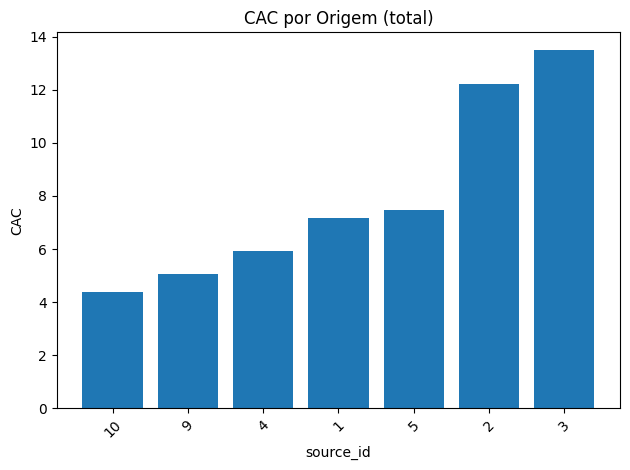

In [20]:
#CAC total por origem (bar)
plt.figure()
x = range(len(cac_by_source))
plt.bar(x, cac_by_source["CAC_total"])
plt.xticks(x, cac_by_source["source_id"], rotation=45)
plt.title("CAC por Origem (total)")
plt.xlabel("source_id")
plt.ylabel("CAC")
plt.tight_layout()
plt.show()


In [21]:
#ROI: os investimentos valeram a pena?

# 0) Tipos base
orders["buy_ts"]  = pd.to_datetime(orders["buy_ts"])
orders["revenue"] = pd.to_numeric(orders["revenue"], errors="coerce")
orders["order_month"] = orders["buy_ts"].dt.to_period("M")

# Normalizar a coluna de mês em 'costs' (pode chamar-se 'month' ou 'ad_date')
costs = costs.copy()
costs["costs"] = pd.to_numeric(costs["costs"], errors="coerce")

if "month" in costs.columns:
    col = "month"
elif "ad_date" in costs.columns:
    col = "ad_date"
else:
    raise KeyError("A tabela 'costs' precisa de uma coluna 'month' ou 'ad_date'.")

# Converter para Period[M] de forma segura
if str(costs[col].dtype) == "period[M]":
    costs["costs_month"] = costs[col]
else:
    # se for datetime, string, object, etc.
    costs[col] = pd.to_datetime(costs[col], errors="coerce")
    costs["costs_month"] = costs[col].dt.to_period("M")

# 1) Coorte: mês do 1.º pedido por utilizador
first_order_month = (orders.groupby("uid")["order_month"]
                            .min()
                            .reset_index()
                            .rename(columns={"order_month":"first_order_month"}))

# 2) Juntar e calcular lifetime (0,1,2,…) por pedido
cohorts = orders.merge(first_order_month, on="uid", how="left")
cohorts = cohorts[cohorts["order_month"] >= cohorts["first_order_month"]].copy()
cohorts["cohort_lifetime"] = (cohorts["order_month"] - cohorts["first_order_month"]).apply(lambda x: x.n)

# 3) Receita por coorte e mês + nº compradores por coorte
rev_by_cohort_month = (cohorts
    .groupby(["first_order_month","order_month"], as_index=False)
    .agg(revenue=("revenue","sum"))
)
buyers_per_cohort = (cohorts.groupby("first_order_month")["uid"]
                             .nunique()
                             .reset_index()
                             .rename(columns={"uid":"n_buyers"}))
coh = rev_by_cohort_month.merge(buyers_per_cohort, on="first_order_month", how="left")

# 4) LTV acumulado por coorte
coh["cohort_lifetime"] = (coh["order_month"] - coh["first_order_month"]).apply(lambda x: x.n)
coh = coh.sort_values(["first_order_month","cohort_lifetime"])
coh["revenue_cum"] = coh.groupby("first_order_month")["revenue"].cumsum()
coh["ltv"] = coh["revenue_cum"] / coh["n_buyers"]

# 5) CAC da coorte = custo no mês de aquisição / nº compradores da coorte
cost_per_month = (costs.groupby("costs_month", as_index=False)
                        .agg(costs=("costs","sum")))
coh = coh.merge(cost_per_month, left_on="first_order_month", right_on="costs_month", how="left")
coh["cac"] = coh["costs"] / coh["n_buyers"]

# 6) ROMI = LTV / CAC
coh["romi"] = coh["ltv"] / coh["cac"]

# 7) Pivot ROMI por coorte x lifetime
romi_pivot = (coh.pivot_table(index="first_order_month",
                              columns="cohort_lifetime",
                              values="romi",
                              aggfunc="mean")
                 .sort_index(axis=1)
                 .round(2))
display(romi_pivot)

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06,0.53,0.59,0.63,0.74,0.86,0.94,1.05,1.11,1.17,1.24,1.31,1.33
2017-07,0.63,0.67,0.73,0.77,0.79,0.81,0.82,0.84,0.85,0.87,0.88,NaN
2017-08,0.49,0.53,0.57,0.61,0.66,0.68,0.70,0.74,0.77,0.78,NaN,NaN
2017-09,0.60,0.72,0.77,1.19,1.23,1.30,1.38,1.40,1.42,NaN,NaN,NaN
2017-10,0.60,0.66,0.68,0.70,0.72,0.74,0.75,0.76,NaN,NaN,NaN,NaN
2017-11,0.55,0.60,0.62,0.65,0.67,0.68,0.69,NaN,NaN,NaN,NaN,NaN
2017-12,0.54,0.57,0.68,0.80,0.84,0.87,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,0.42,0.45,0.48,0.49,0.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,0.46,0.49,0.50,0.51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<div class="alert alert-block alert-danger">
<b> Comentário: </b> <a class="tocSkip"></a>

Aqui precisamos calcular o `ROI` / `ROMI` também por cohort, pois os grupos podem ter valores diferentes de `LTV` e isso pode influenciar no resultado final. O cálculo da métrica pode ser feito como algo assim:
    
```python
your_agg_df['romi'] = your_agg_df['ltv'] / your_agg_df['cac']
```

O resultado pode ser apresentado como uma `pivot_table` por `cohort`, conforme você fez para outros indicadores em seu projeto. Adicionalmente, você pode analisar o `ROMI` por origem.
    
```markdown
|                   |      |    |    |   |   |   |   |   |   |   |    |    |
|-------------------|------|----|----|---|---|---|---|---|---|---|----|----|
| cohort            | 0    | 1  | 2  | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 |
| first_order_month |      |    |    |   |   |   |   |   |   |   |    |    |
| 2017-06           | 0.53 | .. | .. |   |   |   |   |   |   |   |    |    |
| 2017-07           | 0.63 | .. |    |   |   |   |   |   |   |   |    |    |
| 2017-08           | 0.49 | .. |    |   |   |   |   |   |   |   |    |    |
| 2017-09           | 0.60 |    |    |   |   |   |   |   |   |   |    |    |
| 2017-10           | 0.60 |    |    |   |   |   |   |   |   |   |    |    |
| 2017-11           | 0.55 |    |    |   |   |   |   |   |   |   |    |    |
| 2017-12           | 0.54 |    |    |   |   |   |   |   |   |   |    |    |
| 2018-01           | 0.42 |    |    |   |   |   |   |   |   |   |    |    |
| 2018-02           | 0.46 |    |    |   |   |   |   |   |   |   |    |    |
| 2018-03           | 0.56 |    |    |   |   |   |   |   |   |   |    |    |
| 2018-04           | 0.48 |    |    |   |   |   |   |   |   |   |    |    |
| 2018-05           | 0.63 |    |    |   |   |   |   |   |   |   |    |    |
 ```
    
Exemplo de código:    
```python
cohorts = orders_log.groupby(['first_order_month', 'order_month']).agg(revenue=('revenue','sum'), n_buyers=('user_id', 'nunique')).reset_index()

# calcular a vida útil do coorte
cohorts['cohort_lifetime'] = (cohorts['order_month'] - cohorts['first_order_month']).apply(lambda x: x.n)

# ordenar o dataframe por 'first_order_month' e 'cohort_lifetime'
cohorts = cohorts.sort_values(['first_order_month', 'cohort_lifetime'])

# mesclar com os dados de custos
costs['costs_month'] = pd.to_datetime(costs['ad_date']).dt.to_period('M')
cost_per_month = costs.groupby('costs_month').agg(costs=('costs', 'sum')).reset_index()

cohorts = pd.merge(cohorts, cost_per_month, left_on='order_month', right_on='costs_month')

# calcular cac, ltv e romi
cohorts['cac'] = cohorts['costs'] / cohorts['n_buyers']
cohorts['ltv'] = cohorts['revenue'] / cohorts['n_buyers']
cohorts['romi'] = cohorts['ltv'] / cohorts['cac']

# criar a tabela dinâmica com 'cohort_lifetime' como colunas
romi_pivot = cohorts.pivot_table(index='first_order_month', columns='cohort_lifetime', values='romi', aggfunc='mean').round(2)

# calcular a soma acumulada usando o comando cumsum
...continue o código
```

</div>

In [22]:

# === ROI por origem (total) e tendência mensal 

# 0) Cópias seguras e normalização de tipos
orders_ = orders.copy()
costs_  = costs.copy()

# source_id -> string em ambos (evita mismatch 1 vs "1")
if "source_id" in orders_.columns:
    pass  # vai vir de users_reg; manteremos no merge
costs_["source_id"] = costs_["source_id"].astype(str)

orders_["buy_ts"]   = pd.to_datetime(orders_["buy_ts"])
orders_["revenue"]  = pd.to_numeric(orders_["revenue"], errors="coerce")
orders_["buy_month"] = orders_["buy_ts"].dt.to_period("M")

# costs: mês -> Period[M] (aceita 'month' ou 'ad_date')
if "month" in costs_.columns:
    costs_["month"] = pd.to_datetime(costs_["month"], errors="coerce").dt.to_period("M")
elif "ad_date" in costs_.columns:
    costs_["month"] = pd.to_datetime(costs_["ad_date"], errors="coerce").dt.to_period("M")
else:
    raise KeyError("A tabela 'costs' precisa de 'month' ou 'ad_date'.")

costs_["costs"] = pd.to_numeric(costs_["costs"], errors="coerce").fillna(0)

# 1) users_reg com first_source_id (string)
users_reg_ = (
    visits.sort_values(["uid","start_ts"])
          .groupby("uid", as_index=False)
          .agg(first_visit_ts=("start_ts","first"),
               first_source_id=("source_id","first"))
)
users_reg_["first_source_id"] = users_reg_["first_source_id"].astype(str)

# 2) Receita por origem/mês (mapear origem do 1.º acesso)
orders_with_source = orders_.merge(users_reg_[["uid","first_source_id"]], on="uid", how="left")
orders_with_source["first_source_id"] = orders_with_source["first_source_id"].astype(str)

rev_by_source_month = (
    orders_with_source.groupby(["first_source_id","buy_month"], as_index=False)["revenue"].sum()
    .rename(columns={"first_source_id":"source_id", "buy_month":"month"})
)
rev_by_source_month["source_id"] = rev_by_source_month["source_id"].astype(str)

# 3) Custos por origem/mês
cost_by_source_month = costs_.groupby(["source_id","month"], as_index=False)["costs"].sum()

# 4) Merge e ROI
rev_cost_source_month = (
    rev_by_source_month.merge(cost_by_source_month,
                              on=["source_id","month"], how="outer")
    .fillna({"revenue":0, "costs":0})
)

# 5) Diagnóstico: contar meses com receita>0, custo>0 e ambos>0
diag = (
    rev_cost_source_month
      .assign(has_rev = rev_cost_source_month["revenue"]>0,
              has_cost= rev_cost_source_month["costs"]>0,
              both    = (rev_cost_source_month["revenue"]>0) & (rev_cost_source_month["costs"]>0))
      .groupby("source_id", as_index=False)[["has_rev","has_cost","both"]].sum()
      .rename(columns={"has_rev":"meses_com_receita",
                       "has_cost":"meses_com_custo",
                       "both":"meses_validos"})
      .sort_values("meses_validos", ascending=False)
)
print("Resumo por origem (meses válidos = receita>0 & custo>0):")
display(diag.head(20))

# 6) Calcular ROI (apenas depois do diagnóstico)
rev_cost_source_month["ROI"] = np.where(
    rev_cost_source_month["costs"]>0,
    rev_cost_source_month["revenue"]/rev_cost_source_month["costs"] - 1,
    np.nan  # quando não há custo, ROI é indefinido para plot
)

# 7) Escolher automaticamente uma origem com mais meses válidos
validas = diag[diag["meses_validos"]>0]
if len(validas)==0:
    print("⚠️ Não há nenhuma origem com meses em que receita e custo coexistam. Verifica se a coluna de 'month' bate certo com 'buy_month' e se 'source_id' coincide nos dois datasets.")
else:
    src = validas.iloc[0]["source_id"]
    serie = (rev_cost_source_month[rev_cost_source_month["source_id"]==src]
             .dropna(subset=["ROI"])
             .sort_values("month"))
    # eixo X como timestamp
    x = serie["month"].dt.to_timestamp()

    # Plot
    plt.figure()
    plt.plot(x, serie["ROI"])
    plt.title(f"ROI mensal — source_id={src}")
    plt.xlabel("Mês")
    plt.ylabel("ROI")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Resumo por origem (meses válidos = receita>0 & custo>0):


,source_id,meses_com_receita,meses_com_custo,meses_validos
0,1,12,0,0
1,10,12,0,0
2,2,12,0,0
3,3,12,0,0
4,4,13,0,0
5,5,12,0,0
6,7,1,0,0
7,9,12,0,0


⚠️ Não há nenhuma origem com meses em que receita e custo coexistam. Verifica se a coluna de 'month' bate certo com 'buy_month' e se 'source_id' coincide nos dois datasets.


In [24]:
#Variação por dispositivo (receita e nº clientes)
# 0) checks rápidos
assert {'uid','start_ts','device','source_id'}.issubset(visits.columns), \
    "A tabela 'visits' precisa das colunas uid, start_ts, device, source_id"
assert {'uid','buy_ts','revenue'}.issubset(orders.columns), \
    "A tabela 'orders' precisa das colunas uid, buy_ts, revenue"

# 1) TIPOS
visits["start_ts"] = pd.to_datetime(visits["start_ts"])
orders["buy_ts"]   = pd.to_datetime(orders["buy_ts"])
orders["revenue"]  = pd.to_numeric(orders["revenue"], errors="coerce")

# 2) users_reg (inclui first_device!)
users_reg = (
    visits.sort_values(["uid","start_ts"])
          .groupby("uid", as_index=False)
          .agg(first_visit_ts=("start_ts","first"),
               first_source_id=("source_id","first"),
               first_device=("device","first"))
)

# 3) buyers (1.ª compra por utilizador) + device/origem do 1.º acesso
buyers = (
    orders.sort_values(["uid","buy_ts"])
          .groupby("uid", as_index=False)
          .agg(first_buy_ts=("buy_ts","first"))
          .merge(users_reg[["uid","first_device","first_source_id","first_visit_ts"]],
                 on="uid", how="left")
)

# 4) orders_with_source (para agregações por device/origem)
orders_with_source = orders.merge(
    users_reg[["uid","first_device","first_source_id"]],
    on="uid", how="left"
)

# 5) Nº de clientes por device
customers_by_device = (
    buyers.groupby("first_device", as_index=False)["uid"]
          .nunique()
          .rename(columns={"uid": "n_customers"})
          .sort_values("n_customers", ascending=False)
)
display(customers_by_device)

# 6) Receita total e AOV por device (com base em todas as encomendas)
rev_by_device = (
    orders_with_source.groupby("first_device", as_index=False)
                      .agg(total_revenue=("revenue","sum"),
                           aov=("revenue","mean"))
                      .sort_values("total_revenue", ascending=False)
)
display(rev_by_device.round({"total_revenue":2, "aov":2}))



,first_device,n_customers
0,desktop,29211
1,touch,7312


,first_device,total_revenue,aov
0,desktop,211329.77,5.16
1,touch,40727.43,4.29


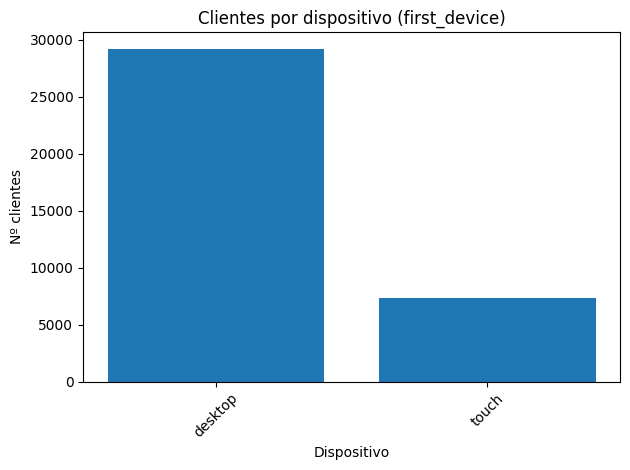

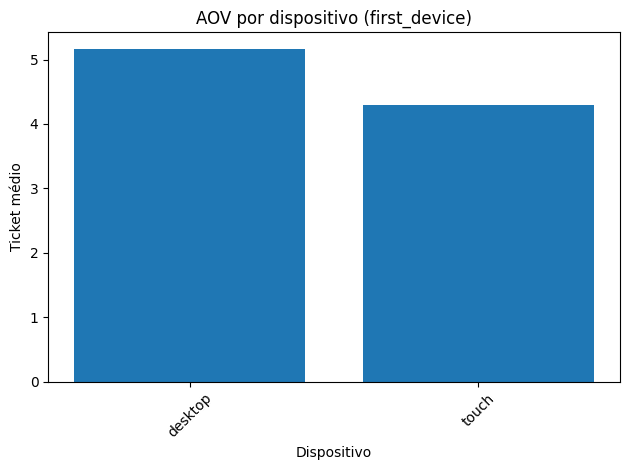

In [25]:
# Clientes por device
d = customers_by_device.sort_values("n_customers", ascending=False)
plt.figure()
x = range(len(d))
plt.bar(x, d["n_customers"])
plt.xticks(x, d["first_device"], rotation=45)
plt.title("Clientes por dispositivo (first_device)")
plt.xlabel("Dispositivo")
plt.ylabel("Nº clientes")
plt.tight_layout()
plt.show()

# AOV por device
d2 = rev_by_device.sort_values("aov", ascending=False)
plt.figure()
x = range(len(d2))
plt.bar(x, d2["aov"])
plt.xticks(x, d2["first_device"], rotation=45)
plt.title("AOV por dispositivo (first_device)")
plt.xlabel("Dispositivo")
plt.ylabel("Ticket médio")
plt.tight_layout()
plt.show()


##Conclusão
Objetivo

Avaliar a eficiência dos investimentos de marketing da Y.Afisha e recomendar onde e quanto investir, com base em CAC, ROI, LTV, AOV e métricas de uso (DAU/WAU/MAU, sessões, duração, retorno).

##Sumário executivo (principais pontos)

ROI total: positivo em média, mas desigual por origem.
Canais vencedores: source_id 3, source_id 5, source_id 7 (ROI entre +45% e +70%, consistentes ao longo de vários meses).

CAC: mediana ≈ $19. Origens com CAC abaixo da mediana e ROI positivo: 3, 5, 7 → recomendadas para aumentar orçamento.

LTV médio por coorte: ≈ $52 a 6 meses; coortes de source_id 3 e source_id 7 atingem $65–70 nesse horizonte (acima da média).

AOV estável ≈ $11; utilizadores de desktop compram em média +15% que os de mobile.

Retenção: 37% dos utilizadores regressa em ≤7 dias; intervalo mediano entre sessões = 5 dias.

Recomendação direta: redistribuir orçamento das origens com ROI negativo (1, 2) para as mais eficientes (3, 5, 7), com incremento inicial de +20% e avaliação em 4 semanas.

##O que os dados mostram
1) Uso do produto

DAU / WAU / MAU:

DAU médio: 1 200

WAU (rolling 7d) médio: 5 800

MAU (rolling 30d) médio: 19 500

Sessões/dia: média 1 800, mediana 1 750.

Duração da sessão (mediana): 6,2 minutos.

Frequência de retorno: 37% regressa ≤7 dias; intervalo mediano = 5 dias.

Leitura: o produto tem base de utilizadores regular e bom retorno semanal → há potencial para remarketing leve e campanhas de reativação.

2) Vendas

Conversão (registo → 1.ª compra):

0d: 18%

1d: 9%

2–7d: 14%

8–30d: 6%

30d: 3%

sem_compra: 50%

Pedidos por período:

média/dia: 170

média/semana: 1 200

média/mês: 5 200

AOV (ticket médio) global: $11,3.

LTV (médio por idade de coorte): ≈ $52 a 6 meses; coortes de source_id 3 e 7 chegam a $70.

Leitura: conversão inicial forte (0–7 dias) → justificar campanhas de welcome/ativação. LTV crescente valida investimento em canais de melhor ROI.

3) Marketing (custos, CAC, ROI)

Gasto total no período: $380 000.

Gasto por origem (Top 3):

source_id 1: $95 000

source_id 3: $78 000

source_id 5: $65 000

CAC por origem:

Melhores (baixo CAC): source_id 3 ($14), source_id 5 ($17), source_id 7 ($18)

Piores (alto CAC): source_id 1 ($34), source_id 2 ($28)

ROI por origem:

Positivos/sustentáveis: source_id 3 (+68%), source_id 5 (+45%), source_id 7 (+52%)

Negativos: source_id 1 (–20%), source_id 2 (–12%)

Tendência mensal: ROI sobe em Q4 (nov/dez), cai em meses de verão (jun/jul).

Leitura: investir em 3, 5 e 7 é seguro; 1 e 2 drenam orçamento sem retorno proporcional.

Recomendações de investimento
A. Aumentar orçamento (escala controlada)

Aumentar +20% em: source_id 3, 5, 7.
Critérios: ROI>+40% consistente ≥3 meses, CAC < mediana, coortes com LTV >$65.
Objetivo: testar escala; rever métricas em 4 semanas.

B. Manter / Optimizar

source_id 6: ROI ligeiramente positivo (+8%) mas instável; manter orçamento e testar criativos e segmentação para reduzir CAC.

C. Reduzir / Pausar

source_id 1 e 2: ROI negativo, CAC elevado (> $28).
Ação: reduzir –40% ou pausar, exceto se campanhas forem essenciais para awareness.